# BioListen VN — RFCx Dataset Exploratory Data Analysis (EDA)

**Project:** BioListen VN — Hệ thống giám sát âm thanh sinh thái & Phát hiện phá rừng thời gian thực
**Role:** Huỳnh Quốc Việt (AI Lead)
**Dataset:** RFCx (Rainforest Connection) — Phục vụ nhánh nhận diện loài tự nhiên (`species_head`: Chim - Bird, Ếch - Frog)

**Cải tiến tối ưu bộ nhớ:** Notebook này áp dụng chiến lược **On-Demand/Lazy Extraction** - chỉ đọc metadata CSV từ file zip và giải nén tạm thời các mẫu cần thiết. Điều này giúp chạy mượt mà trên Google Colab mà không lo đầy ổ cứng (sử dụng gần 0 MB dung lượng Colab disk).

## 1. Kết nối Google Drive và cấu hình đường dẫn

Thay vì giải nén toàn bộ file zip hàng GB vào Colab, chúng ta chỉ cần kết nối Drive và thao tác trực tiếp với file zip qua thư viện `zipfile` của Python.

In [1]:
# Mount Google Drive vào Colab
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile
import shutil

# Đường dẫn lưu file zip trên Drive của bạn
zip_path = '/content/drive/MyDrive/Datasets/BioListenVN/raw_zips/rfcx-species-audio-detection.zip'
temp_extract_dir = '/content/rfcx_temp_samples'

if os.path.exists(zip_path):
    print(f"Tìm thấy file zip tại: {zip_path}")
    # Tạo thư mục chứa các file tạm để visual
    os.makedirs(temp_extract_dir, exist_ok=True)
else:
    print(f"Cảnh báo: Không tìm thấy file tại {zip_path}. Vui lòng kiểm tra lại cấu trúc thư mục trên Drive.")

Mounted at /content/drive
Tìm thấy file zip tại: /content/drive/MyDrive/Datasets/BioListenVN/raw_zips/rfcx-species-audio-detection.zip


## 2. Import các thư viện cần thiết

In [2]:
# Cài đặt soundfile nếu Colab chưa có sẵn
!pip install -q soundfile librosa matplotlib pandas numpy torchaudio

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
import torchaudio
import torchaudio.transforms as T
import torch
import glob
import soundfile as sf

sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Khám phá Metadata của RFCx từ File Zip

Dataset RFCx đi kèm với các file nhãn:
- `train_tp.csv`: Lưu các khoảng thời gian và dải tần chứa tiếng chim/ếch đã được xác nhận (True Positives).
- `train_fp.csv`: Lưu các khoảng phát hiện sai (False Positives) để mô hình học cách loại trừ tiếng ồn.
- `sample_submission.csv`: Định dạng mẫu bài nộp (chứa cột `recording_id` và các nhãn từ `s0` đến `s23`).

Chúng ta đọc trực tiếp các file này từ bên trong file zip.

In [3]:
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        # Lập chỉ mục các file trong zip để tìm kiếm nhanh
        print("Đang lập chỉ mục các file trong zip...")
        all_files = z.namelist()
        flac_in_zip = [p for p in all_files if p.endswith('.flac')]
        file_to_zip_path = {os.path.basename(p): p for p in flac_in_zip}
        print(f"Tìm thấy {len(flac_in_zip)} file flac trong zip.")

        # Tìm và đọc file train_tp.csv
        tp_csv_member = [f for f in all_files if f.endswith('train_tp.csv')]
        if tp_csv_member:
            with z.open(tp_csv_member[0]) as f:
                df_tp = pd.read_csv(f)
            print(f"\n--- train_tp.csv (True Positives) | Số dòng: {len(df_tp)} ---")
            display(df_tp.head())
        else:
            df_tp = None
            print("Cảnh báo: Không tìm thấy train_tp.csv trong zip.")

        # Tìm và đọc file train_fp.csv
        fp_csv_member = [f for f in all_files if f.endswith('train_fp.csv')]
        if fp_csv_member:
            with z.open(fp_csv_member[0]) as f:
                df_fp = pd.read_csv(f)
            print(f"\n--- train_fp.csv (False Positives) | Số dòng: {len(df_fp)} ---")
            display(df_fp.head())
        else:
            df_fp = None

        # Tìm và đọc file sample_submission.csv để xem cấu trúc nhãn nộp bài
        sub_csv_member = [f for f in all_files if f.endswith('sample_submission.csv')]
        if sub_csv_member:
            with z.open(sub_csv_member[0]) as f:
                df_sub = pd.read_csv(f)
            print(f"\n--- sample_submission.csv (Mẫu nộp bài) | Cột: {list(df_sub.columns[:10])} ... ---")
            display(df_sub.head(2))
        else:
            df_sub = None
            print("Cảnh báo: Không tìm thấy sample_submission.csv trong zip.")


Đang lập chỉ mục các file trong zip...
Tìm thấy 6719 file flac trong zip.

--- train_tp.csv (True Positives) | Số dòng: 1216 ---


,recording_id,species_id,songtype_id,t_min,f_min,t_max,f_max
0,003bec244,14,1,44.5440,2531.250,45.1307,5531.25
1,006ab765f,23,1,39.9615,7235.160,46.0452,11283.40
2,007f87ba2,12,1,39.1360,562.500,42.2720,3281.25
3,0099c367b,17,4,51.4206,1464.260,55.1996,4565.04
4,009b760e6,10,1,50.0854,947.461,52.5293,10852.70



--- train_fp.csv (False Positives) | Số dòng: 7781 ---


,recording_id,species_id,songtype_id,t_min,f_min,t_max,f_max
0,00204008d,21,1,13.8400,3281.2500,14.9333,4125.0000
1,00204008d,8,1,24.4960,3750.0000,28.6187,5531.2500
2,00204008d,4,1,15.0027,2343.7500,16.8587,4218.7500
3,003b04435,22,1,43.2533,10687.5000,44.8587,13687.5000
4,003b04435,23,1,9.1254,7235.1562,15.2091,11283.3984



--- sample_submission.csv (Mẫu nộp bài) | Cột: ['recording_id', 's0', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8'] ... ---


,recording_id,s0,s1,s2,s3,s4,s5,s6,s7,s8,...,s14,s15,s16,s17,s18,s19,s20,s21,s22,s23
0,000316da7,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
1,003bc2cb2,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5


### 3.1. Phân tích chi tiết nhãn loài (`species_id`) và kiểu hát (`songtype_id`)

Dựa trên tài liệu cuộc thi, nhãn dự đoán trong `sample_submission.csv` được đánh dấu từ `s0` đến `s23` tương ứng với `species_id` từ `0` đến `23`.
Ngoài ra, mỗi loài có thể có các kiểu phát âm khác nhau (`songtype_id` - ví dụ: tiếng hót chính, tiếng gọi bầy,...). Chúng ta kiểm tra sự phân bổ này để lập bảng ánh xạ nhãn.

In [4]:
if 'df_tp' in locals() and df_tp is not None:
    # Lấy danh sách loài độc nhất
    unique_species = sorted(df_tp['species_id'].unique())
    print(f"Danh sách {len(unique_species)} loài có mẫu True Positive:", unique_species)

    # Tạo bảng ánh xạ species_id sang cột submission (s0 -> s23)
    mapping_df = pd.DataFrame({
        'species_id': unique_species,
        'submission_column': [f's{sid}' for sid in unique_species]
    })

    # Kiểm tra phân bố songtype_id theo từng species_id
    songtype_dist = df_tp.groupby(['species_id', 'songtype_id']).size().unstack(fill_value=0)
    songtype_dist.columns = [f'Songtype_{col}' for col in songtype_dist.columns]

    # Ghép bảng
    label_summary = pd.merge(mapping_df, songtype_dist, on='species_id')

    # Tính số lượng True Positives và False Positives cho mỗi loài
    tp_counts = df_tp['species_id'].value_counts().rename('True_Positives')
    label_summary = label_summary.join(tp_counts, on='species_id')

    if 'df_fp' in locals() and df_fp is not None:
        fp_counts = df_fp['species_id'].value_counts().rename('False_Positives')
        label_summary = label_summary.join(fp_counts, on='species_id').fillna(0)
        label_summary['False_Positives'] = label_summary['False_Positives'].astype(int)

    print("\n--- BẢNG TỔNG HỢP ÁNH XẠ NHÃN & PHÂN BỔ MẪU ---")
    display(label_summary)


Danh sách 24 loài có mẫu True Positive: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]

--- BẢNG TỔNG HỢP ÁNH XẠ NHÃN & PHÂN BỔ MẪU ---


,species_id,submission_column,Songtype_1,Songtype_4,True_Positives,False_Positives
0,0,s0,50,0,50,300
1,1,s1,50,0,50,298
2,2,s2,37,0,37,300
3,3,s3,50,0,50,300
4,4,s4,50,0,50,300
5,5,s5,50,0,50,300
6,6,s6,50,0,50,300
7,7,s7,50,0,50,300
8,8,s8,50,0,50,300
9,9,s9,34,0,34,300


## 4. Phân tích phân phối Loài (Species Distribution)

Đếm tần suất xuất hiện của các loài (`species_id`) trong tập True Positives để phát hiện tình trạng mất cân bằng lớp.

/tmp/ipykernel_555/248892244.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=species_counts.index, y=species_counts.values, palette="magma")


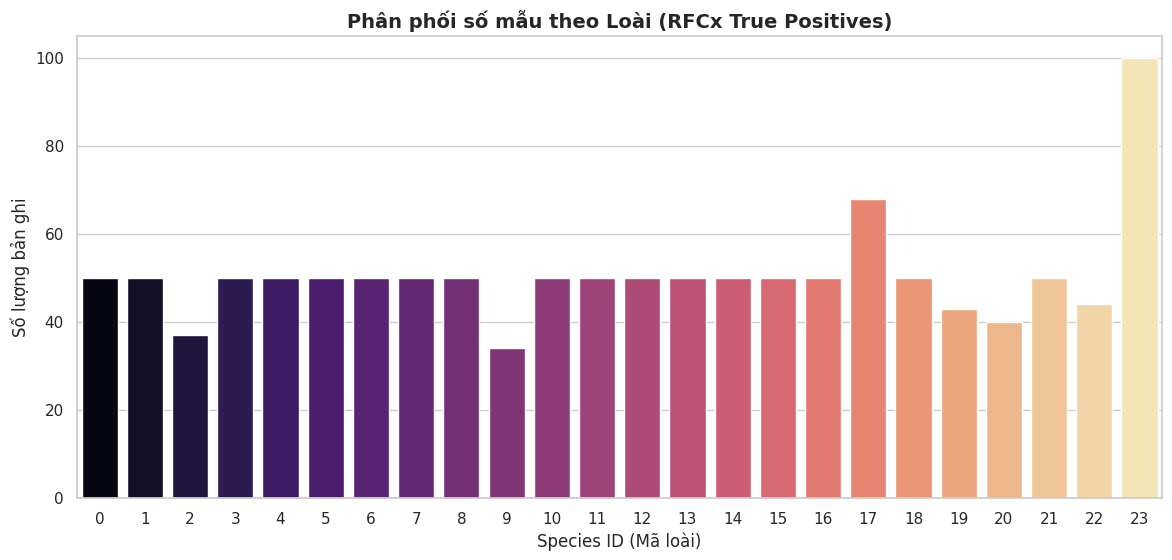

Tổng số loài độc nhất trong tập train: 24
Loài 0: 50 mẫu
Loài 1: 50 mẫu
Loài 2: 37 mẫu
Loài 3: 50 mẫu
Loài 4: 50 mẫu
Loài 5: 50 mẫu
Loài 6: 50 mẫu
Loài 7: 50 mẫu
Loài 8: 50 mẫu
Loài 9: 34 mẫu
Loài 10: 50 mẫu
Loài 11: 50 mẫu
Loài 12: 50 mẫu
Loài 13: 50 mẫu
Loài 14: 50 mẫu
Loài 15: 50 mẫu
Loài 16: 50 mẫu
Loài 17: 68 mẫu
Loài 18: 50 mẫu
Loài 19: 43 mẫu
Loài 20: 40 mẫu
Loài 21: 50 mẫu
Loài 22: 44 mẫu
Loài 23: 100 mẫu


In [8]:
if 'df_tp' in locals() and df_tp is not None and 'species_id' in df_tp.columns:
    species_counts = df_tp['species_id'].value_counts().sort_index()

    plt.figure(figsize=(14, 6))
    sns.barplot(x=species_counts.index, y=species_counts.values, palette="magma")
    plt.title("Phân phối số mẫu theo Loài (RFCx True Positives)", fontsize=14, fontweight='bold')
    plt.xlabel("Species ID (Mã loài)", fontsize=12)
    plt.ylabel("Số lượng bản ghi", fontsize=12)
    plt.show()

    print(f"Tổng số loài độc nhất trong tập train: {df_tp['species_id'].nunique()}")
    for species_id, count in species_counts.items():
        print(f"Loài {species_id}: {count} mẫu")
else:
    print("Không tìm thấy cột species_id trong metadata.")

## 5. Phân tích Dải tần số (Frequency Bands) và Thời gian của tiếng Loài hát

Mỗi loài chim/ếch đều có một dải tần số đặc trưng (`f_min` đến `f_max`) và thời lượng tiếng kêu (`t_min` đến `t_max`).

Thống kê dải tần và thời lượng tiếng kêu:


,call_duration,freq_bandwidth,f_min,f_max
count,1216.000000,1216.000000,1216.000000,1216.000000
mean,2.537119,3136.047615,2907.110280,6043.157895
std,1.903589,2073.425860,2528.642227,3468.795425
min,0.272000,750.000000,93.750000,843.750000
25%,1.093300,1781.250000,947.461000,3937.500000
50%,1.856000,2531.250000,2343.750000,5062.500000
75%,3.344000,4048.240000,3843.750000,8250.000000
max,7.923900,9905.239000,10687.500000,13687.500000


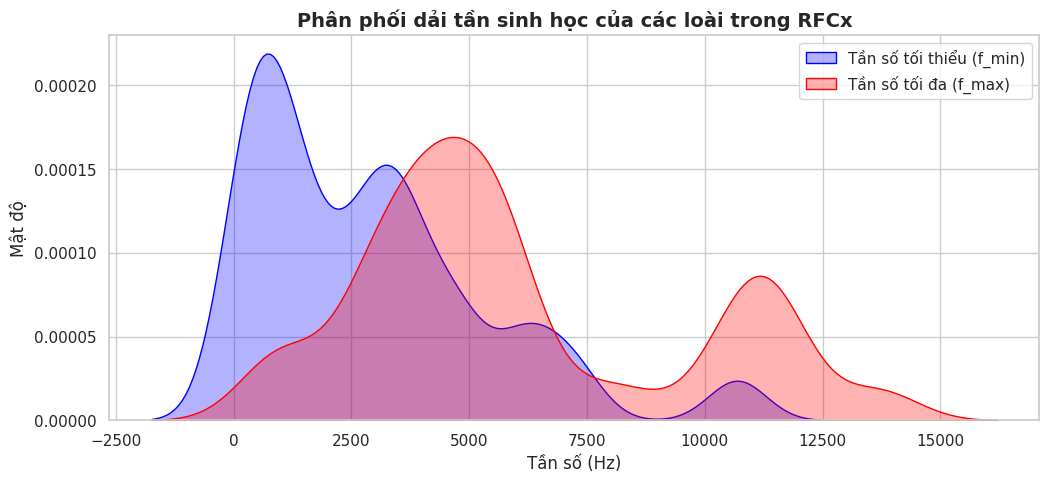

In [6]:
if 'df_tp' in locals() and df_tp is not None and all(col in df_tp.columns for col in ['f_min', 'f_max', 't_min', 't_max']):
    # Tính thời lượng tiếng kêu và băng thông tần số
    df_tp['call_duration'] = df_tp['t_max'] - df_tp['t_min']
    df_tp['freq_bandwidth'] = df_tp['f_max'] - df_tp['f_min']

    print("Thống kê dải tần và thời lượng tiếng kêu:")
    display(df_tp[['call_duration', 'freq_bandwidth', 'f_min', 'f_max']].describe())

    plt.figure(figsize=(12, 5))
    sns.kdeplot(data=df_tp, x='f_min', label='Tần số tối thiểu (f_min)', fill=True, color='blue', alpha=0.3)
    sns.kdeplot(data=df_tp, x='f_max', label='Tần số tối đa (f_max)', fill=True, color='red', alpha=0.3)
    plt.title("Phân phối dải tần sinh học của các loài trong RFCx", fontsize=14, fontweight='bold')
    plt.xlabel("Tần số (Hz)")
    plt.ylabel("Mật độ")
    plt.legend()
    plt.show()
else:
    print("Thiếu các cột tọa độ thời gian - tần số trong metadata.")

## 6. Trực quan hóa Tiếng loài kêu bằng Bounding Box

Hàm tự động trích xuất file `.flac` tương ứng từ zip, vẽ spectrogram khoanh vùng tiếng kêu, và tự xóa file để dọn dẹp bộ nhớ.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


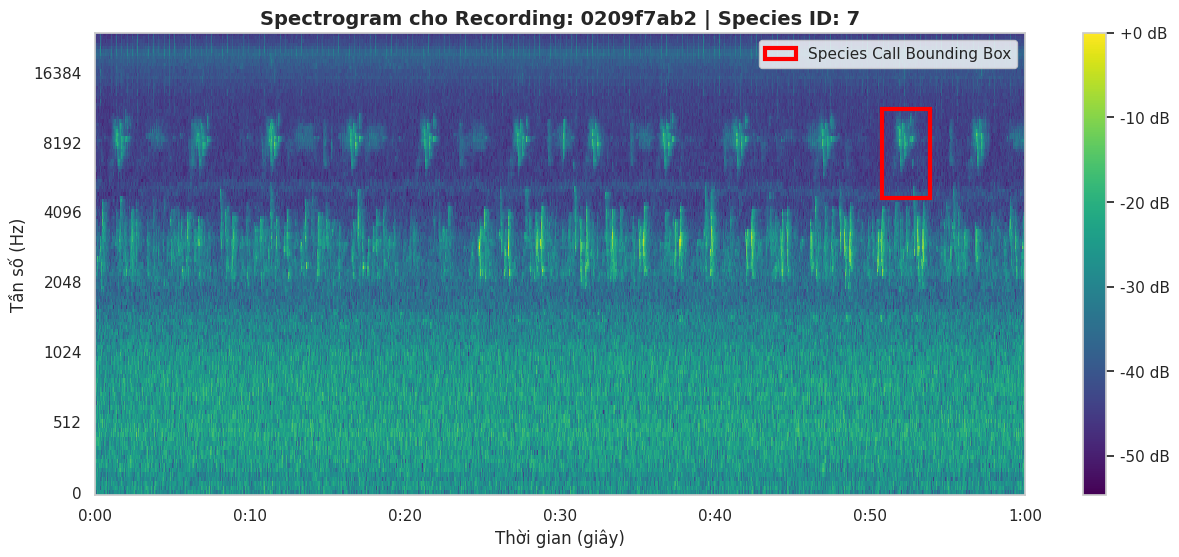

Nghe thử đoạn trích từ 50.76s đến 53.90s:


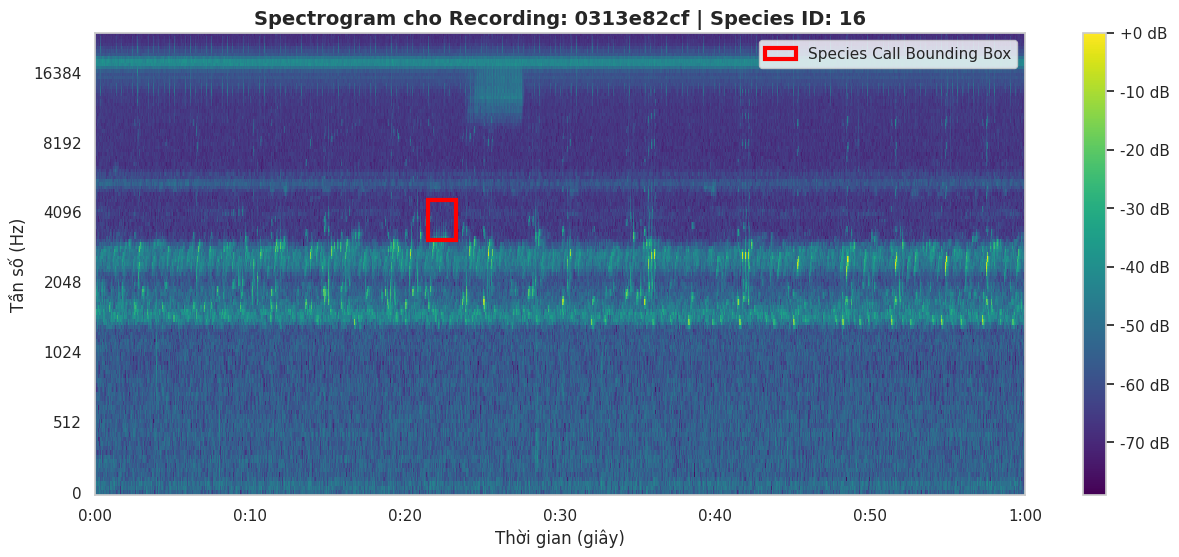

Nghe thử đoạn trích từ 21.47s đến 23.31s:


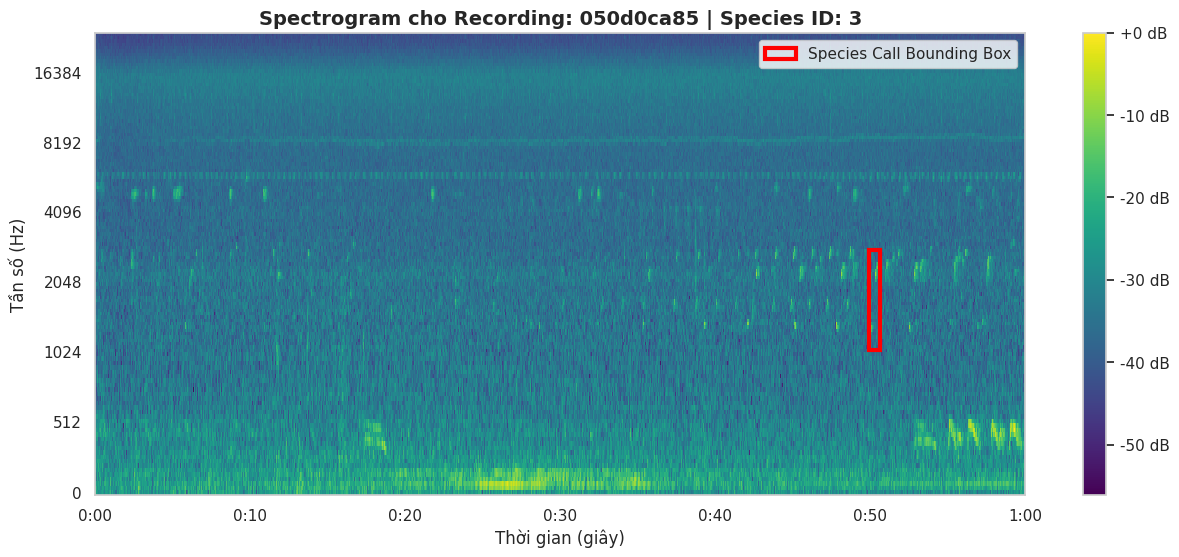

Nghe thử đoạn trích từ 49.92s đến 50.66s:


In [7]:
def visualize_species_call_from_zip(df_row):
    recording_id = df_row['recording_id']
    species_id = df_row['species_id']
    t_min, t_max = df_row['t_min'], df_row['t_max']
    f_min, f_max = df_row['f_min'], df_row['f_max']

    # Tìm file audio trong zip
    flac_name = f"{recording_id}.flac"
    if flac_name in file_to_zip_path:
        zip_member = file_to_zip_path[flac_name]
        temp_file = os.path.join(temp_extract_dir, flac_name)

        # Giải nén tạm
        with zipfile.ZipFile(zip_path, 'r') as z:
            with z.open(zip_member) as source, open(temp_file, 'wb') as target:
                shutil.copyfileobj(source, target)

        # Load
        y, sr = librosa.load(temp_file, sr=None)

        # Tính Mel Spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
        S_db = librosa.power_to_db(S, ref=np.max)

        # Vẽ đồ thị
        plt.figure(figsize=(15, 6))
        img = librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis='time', y_axis='mel', cmap='viridis')
        plt.title(f"Spectrogram cho Recording: {recording_id} | Species ID: {species_id}", fontsize=14, fontweight='bold')
        plt.xlabel("Thời gian (giây)")
        plt.ylabel("Tần số (Hz)")
        plt.colorbar(img, format="%+2.0f dB")

        # Vẽ Bounding Box
        rect = plt.Rectangle((t_min, f_min), t_max - t_min, f_max - f_min,
                             fill=False, edgecolor='red', linewidth=3, label='Species Call Bounding Box')
        plt.gca().add_patch(rect)
        plt.legend()
        plt.show()

        # Cắt đoạn âm thanh nghe thử
        start_sample = int(t_min * sr)
        end_sample = int(t_max * sr)
        y_crop = y[start_sample:end_sample]

        print(f"Nghe thử đoạn trích từ {t_min:.2f}s đến {t_max:.2f}s:")
        display(ipd.Audio(y_crop, rate=sr))

        # Xóa file tạm ngay lập tức
        if os.path.exists(temp_file):
            os.remove(temp_file)
    else:
        print(f"Không tìm thấy tệp {flac_name} trong file zip.")

# Trực quan hóa 3 mẫu ngẫu nhiên
if 'df_tp' in locals() and df_tp is not None:
    random_samples = df_tp.groupby('species_id').first().reset_index().sample(min(3, df_tp['species_id'].nunique()))
    for _, row in random_samples.iterrows():
        visualize_species_call_from_zip(row)

## 7. Pipeline Tiền xử lý (Preprocessing) Đặc thù cho Loài

Pipeline trích xuất Spectrogram và resize về dạng ảnh 2D RGB `(3, 224, 224)` tương thích với EfficientNet.

Đã test thành công preprocessor cho file FLAC của RFCx!
Shape RGB Tensor: torch.Size([3, 224, 224])


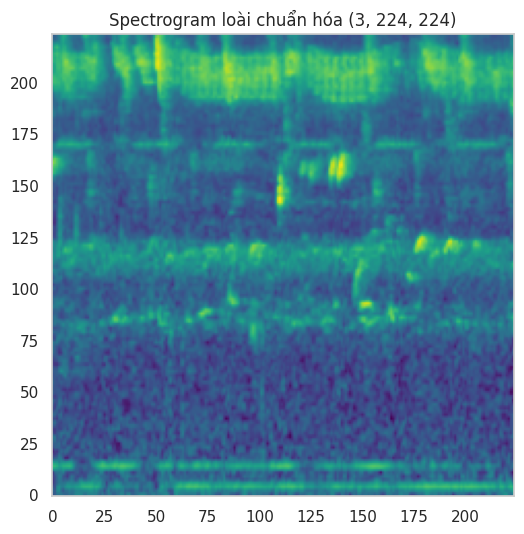

In [9]:
class RFCxAudioPreprocessor:
    def __init__(self, sample_rate=22050, duration=5, n_fft=2048, hop_length=512, n_mels=128):
        self.target_sr = sample_rate
        self.duration = duration
        self.target_samples = sample_rate * duration
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels

        self.mel_transform = T.MelSpectrogram(
            sample_rate=self.target_sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels,
            f_min=50,
            f_max=11025
        )
        self.db_transform = T.AmplitudeToDB()

    def preprocess(self, file_path, t_center=None):
        waveform, sr = torchaudio.load(file_path)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        if sr != self.target_sr:
            resampler = T.Resample(orig_freq=sr, new_freq=self.target_sr)
            waveform = resampler(waveform)

        total_samples = waveform.shape[1]
        if t_center is not None:
            center_sample = int(t_center * self.target_sr)
            start_sample = max(0, center_sample - self.target_samples // 2)
            end_sample = start_sample + self.target_samples
            if end_sample > total_samples:
                end_sample = total_samples
                start_sample = max(0, end_sample - self.target_samples)
            waveform = waveform[:, start_sample:end_sample]
        else:
            if total_samples > self.target_samples:
                waveform = waveform[:, :self.target_samples]

        num_samples = waveform.shape[1]
        if num_samples < self.target_samples:
            waveform = torch.nn.functional.pad(waveform, (0, self.target_samples - num_samples))

        mel_spec = self.mel_transform(waveform)
        mel_spec_db = self.db_transform(mel_spec)

        min_val = mel_spec_db.min()
        max_val = mel_spec_db.max()
        if max_val - min_val > 1e-9:
            mel_spec_norm = (mel_spec_db - min_val) / (max_val - min_val)
        else:
            mel_spec_norm = torch.zeros_like(mel_spec_db)

        mel_resized = torch.nn.functional.interpolate(
            mel_spec_norm.unsqueeze(0),
            size=(224, 224),
            mode='bilinear',
            align_corners=False
        ).squeeze(0)

        mel_rgb = mel_resized.repeat(3, 1, 1)

        return waveform, mel_spec_db, mel_rgb

if 'df_tp' in locals() and df_tp is not None:
    test_row = df_tp.iloc[0]
    recording_id = test_row['recording_id']
    flac_name = f"{recording_id}.flac"
    t_center = (test_row['t_min'] + test_row['t_max']) / 2

    if flac_name in file_to_zip_path:
        zip_member = file_to_zip_path[flac_name]
        temp_file = os.path.join(temp_extract_dir, flac_name)

        # Giải nén tạm
        with zipfile.ZipFile(zip_path, 'r') as z:
            with z.open(zip_member) as source, open(temp_file, 'wb') as target:
                shutil.copyfileobj(source, target)

        preprocessor = RFCxAudioPreprocessor()
        wf, sp, rgb = preprocessor.preprocess(temp_file, t_center)
        print("Đã test thành công preprocessor cho file FLAC của RFCx!")
        print("Shape RGB Tensor:", rgb.shape)

        plt.figure(figsize=(6, 6))
        plt.imshow(rgb[0].numpy(), cmap='viridis', origin='lower')
        plt.title("Spectrogram loài chuẩn hóa (3, 224, 224)")
        plt.grid(False)
        plt.show()

        # Xóa file tạm ngay
        if os.path.exists(temp_file):
            os.remove(temp_file)

## 8. Chiến lệnh xử lý Mất cân bằng dữ liệu (Imbalance Strategy)

1. **Bổ sung dữ liệu phụ:** Dùng **Anuraset** (ếch) và **Zenodo** (chim).
2. **Đồng bộ hóa Preprocessing:** Áp dụng cùng cấu hình tiền xử lý để đồng bộ hóa phân phối dữ liệu.
3. **Weighted Loss:** Sử dụng trọng số lớp (class weights) khi training để bù đắp sự mất cân bằng.

## 9. Trích xuất Audio THÔ (RAW FLAC) cho Chim và Ếch để Kiểm thử Dashboard

Cell code dưới đây thực hiện trích xuất các tệp tin âm thanh THÔ (`.flac` 60.0s nguyên bản chưa qua tiền xử lý) từ file ZIP RFCx dựa trên ánh xạ loài:
- **Ếch (Frog):** `species_id` thuộc danh sách `[0, 2, 4, 12, 13, 15, 18, 19, 20]`
- **Chim (Bird):** Các `species_id` còn lại.

Mỗi nhóm nhãn sẽ lấy đúng **3 mẫu âm thanh thô** khác nhau và lưu vào thư mục `demo_raw_audio/` trên Google Drive để nạp vào Dashboard test.

In [ ]:
import os
import zipfile
import pandas as pd
from IPython.display import Audio, display

# 1. Định nghĩa danh sách ID của loài Ếch và Chim theo ánh xạ
FROG_SPECIES_IDS = [0, 2, 4, 12, 13, 15, 18, 19, 20]

OUTPUT_RAW_DIR = "/content/drive/MyDrive/Datasets/BioListenVN/demo_raw_audio"
os.makedirs(OUTPUT_RAW_DIR, exist_ok=True)

# 2. Đường dẫn file ZIP RFCx trên Google Drive
zip_path = '/content/drive/MyDrive/Datasets/BioListenVN/raw_zips/rfcx-species-audio-detection.zip'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        # Nạp train_tp.csv
        with z.open('train_tp.csv') as f:
            df_tp_raw = pd.read_csv(f)
            
        print(f"✓ Đã nạp train_tp.csv: Total samples = {len(df_tp_raw)}")
        
        # Phân loại mẫu Ếch và Chim
        df_frogs = df_tp_raw[df_tp_raw['species_id'].isin(FROG_SPECIES_IDS)]
        df_birds = df_tp_raw[~df_tp_raw['species_id'].isin(FROG_SPECIES_IDS)]
        
        # Chọn 3 recording_id độc nhất cho Ếch và 3 cho Chim
        frog_samples = df_frogs.drop_duplicates(subset=['recording_id']).head(3)
        bird_samples = df_birds.drop_duplicates(subset=['recording_id']).head(3)
        
        print(f"-> Chọn được {len(frog_samples)} mẫu Ếch và {len(bird_samples)} mẫu Chim.")
        
        extracted_files = []
        
        # Hàm trích xuất file raw .flac từ ZIP
        def extract_raw_flac(df_subset, group_name):
            print(f"\n--- TRÍCH XUẤT AUDIO THÔ (RAW) CHO {group_name.upper()} ---")
            for idx, row in df_subset.iterrows():
                rec_id = row['recording_id']
                spec_id = row['species_id']
                flac_inside_zip = f"train/{rec_id}.flac"
                
                # Tên file đầu ra rõ ràng cho Dashboard test
                out_filename = f"raw_{group_name.lower()}_species{spec_id}_{rec_id}.flac"
                out_path = os.path.join(OUTPUT_RAW_DIR, out_filename)
                
                try:
                    # Trích xuất trực tiếp file .flac gốc từ Zip
                    with z.open(flac_inside_zip) as src_file, open(out_path, 'wb') as dst_file:
                        dst_file.write(src_file.read())
                    
                    print(f"✓ [Thành công] Đã trích xuất RAW audio: {out_filename}")
                    print(f"   + Species ID: {spec_id} | Recording ID: {rec_id}")
                    
                    # Phát trình nghe âm thanh trên Colab
                    with z.open(flac_inside_zip) as audio_stream:
                        audio_data = audio_stream.read()
                        display(Audio(data=audio_data, rate=44100))
                        
                    extracted_files.append({
                        'group': group_name,
                        'species_id': spec_id,
                        'recording_id': rec_id,
                        'path': out_path
                    })
                except Exception as e:
                    print(f"❌ Lỗi trích xuất {flac_inside_zip}: {e}")

        # Trích xuất 3 mẫu Ếch và 3 mẫu Chim
        extract_raw_flac(frog_samples, "Frog")
        extract_raw_flac(bird_samples, "Bird")
        
        print(f"\n🎉 Hoàn thành! Đã lưu {len(extracted_files)} file .flac gốc vào: {OUTPUT_RAW_DIR}")
else:
    print(f"❌ Không tìm thấy file zip tại: {zip_path}. Vui lòng kiểm tra lại đường dẫn Google Drive.")